In [1]:
%pip install numpy scipy --upgrade
%pip install ipykernel jupyter pandas nltk wordcloud matplotlib seaborn scikit-learn gensim
%pip install wget

Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
Using cached scipy-1.13.1-cp310-cp310-win_amd64.whl (46.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.5
    Uninstalling numpy-2.2.5:
      Successfully uninstalled numpy-2.2.5
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.2
    Uninstalling scipy-1.15.2:
      Successfully uninstalled scipy-1.15.2
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import json
import gzip
import pandas as pd
import wget
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\kage-\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kage-\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
ruta_comprimido = 'reviews_Sports_and_Outdoors_5.json.gz'
wget.download('http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Sports_and_Outdoors_5.json.gz', ruta_comprimido)
data = []
with gzip.open(ruta_comprimido, 'rt', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line.strip()))

In [4]:
# Crear DataFrame con los datos
df = pd.DataFrame(data)

# Mostrar las primeras filas del DataFrame
print("Primeras 5 filas del dataset:")
display(df.head())

# Mostrar información general del DataFrame
print("\nInformación del DataFrame:")
display(df.info())

Primeras 5 filas del dataset:


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,AIXZKN4ACSKI,1881509818,David Briner,"[0, 0]",This came in on time and I am veru happy with ...,5.0,Woks very good,1390694400,"01 26, 2014"
1,A1L5P841VIO02V,1881509818,Jason A. Kramer,"[1, 1]",I had a factory Glock tool that I was using fo...,5.0,Works as well as the factory tool,1328140800,"02 2, 2012"
2,AB2W04NI4OEAD,1881509818,J. Fernald,"[2, 2]",If you don't have a 3/32 punch or would like t...,4.0,"It's a punch, that's all.",1330387200,"02 28, 2012"
3,A148SVSWKTJKU6,1881509818,"Jusitn A. Watts ""Maverick9614""","[0, 0]",This works no better than any 3/32 punch you w...,4.0,It's a punch with a Glock logo.,1328400000,"02 5, 2012"
4,AAAWJ6LW9WMOO,1881509818,Material Man,"[0, 0]",I purchased this thinking maybe I need a speci...,4.0,"Ok,tool does what a regular punch does.",1366675200,"04 23, 2013"



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296337 entries, 0 to 296336
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   reviewerID      296337 non-null  object 
 1   asin            296337 non-null  object 
 2   reviewerName    294935 non-null  object 
 3   helpful         296337 non-null  object 
 4   reviewText      296337 non-null  object 
 5   overall         296337 non-null  float64
 6   summary         296337 non-null  object 
 7   unixReviewTime  296337 non-null  int64  
 8   reviewTime      296337 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 20.3+ MB


None

Tamaño del vocabulario: 315906


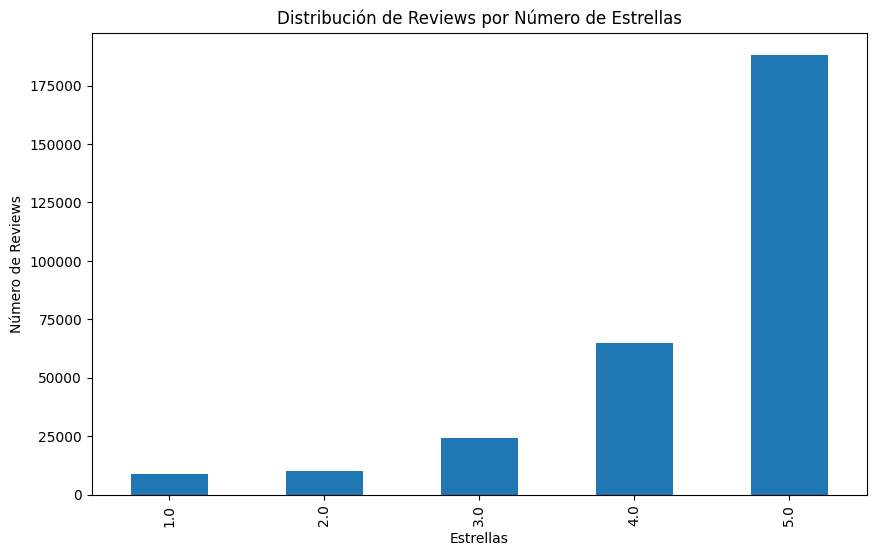

In [ ]:
import re

# Tokenización y limpieza básica
def preprocess_text(text):
    # Convertir a minúsculas
    text = text.lower()   
    # Eliminar signos de puntuación y caracteres especiales
    text = re.sub(r'[^\w\s]', '', text)   
    # Tokenización
    tokens = word_tokenize(text)   
    # Eliminar stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token.isalnum() and token not in stop_words]
    
    return tokens

# Crear vocabulario
all_tokens = []
for review in df['reviewText']:
    tokens = preprocess_text(review)
    all_tokens.extend(tokens)

# Cardinalidad del vocabulario
vocabulary = set(all_tokens)
print(f"Tamaño del vocabulario: {len(vocabulary)}")

# Distribución de reviews por estrellas
plt.figure(figsize=(10, 6))
df['overall'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución de Reviews por Número de Estrellas')
plt.xlabel('Estrellas')
plt.ylabel('Número de Reviews')
plt.show()

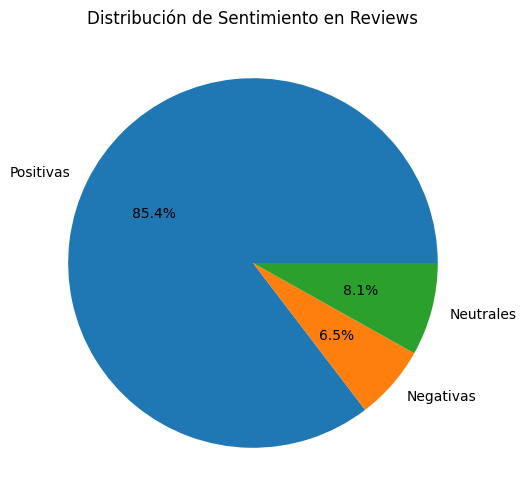

In [8]:
# Consideramos positivas >= 4 estrellas, negativas <= 2 estrellas
positivas = df[df['overall'] >= 4].shape[0]
negativas = df[df['overall'] <= 2].shape[0]
neutrales = df[df['overall'] == 3].shape[0]

plt.figure(figsize=(8, 6))
plt.pie([positivas, negativas, neutrales], 
        labels=['Positivas', 'Negativas', 'Neutrales'],
        autopct='%1.1f%%')
plt.title('Distribución de Sentimiento en Reviews')
plt.show()

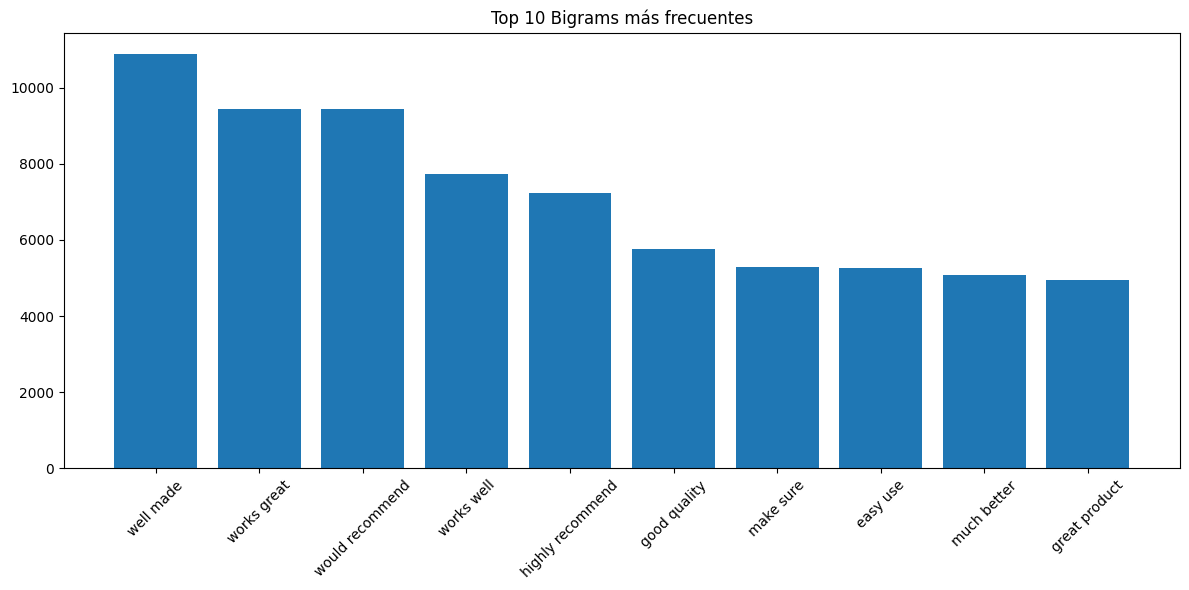

In [9]:
# N-grams para saber las palabras más frecuentes:
from nltk import ngrams

def get_top_ngrams(texts, n, top_k=10):
    all_ngrams = []
    for text in texts:
        tokens = preprocess_text(text)
        text_ngrams = list(ngrams(tokens, n))
        all_ngrams.extend(text_ngrams)
    
    return Counter(all_ngrams).most_common(top_k)

# Visualizar top 10 bigrams
top_bigrams = get_top_ngrams(df['reviewText'], 2)
plt.figure(figsize=(12, 6))
plt.bar([' '.join(x[0]) for x in top_bigrams], [x[1] for x in top_bigrams])
plt.xticks(rotation=45)
plt.title('Top 10 Bigrams más frecuentes')
plt.tight_layout()
plt.show()

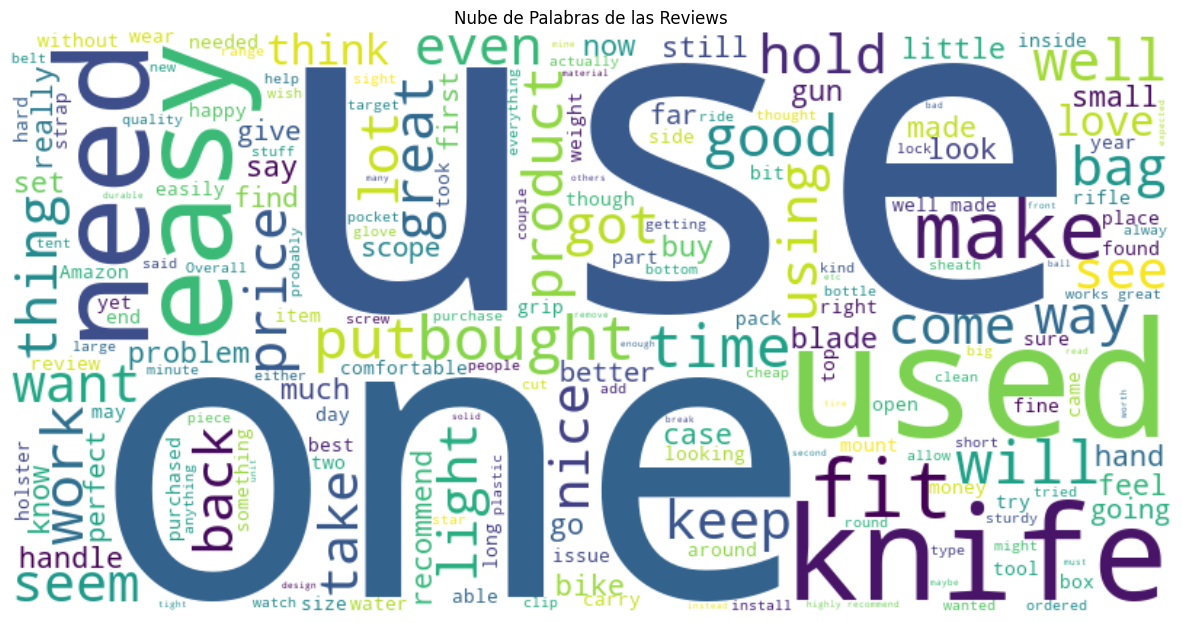

In [11]:
# Crear texto combinado para la nube de palabras
text = ' '.join(df['reviewText'])

# Generar nube de palabras
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de las Reviews')
plt.show()

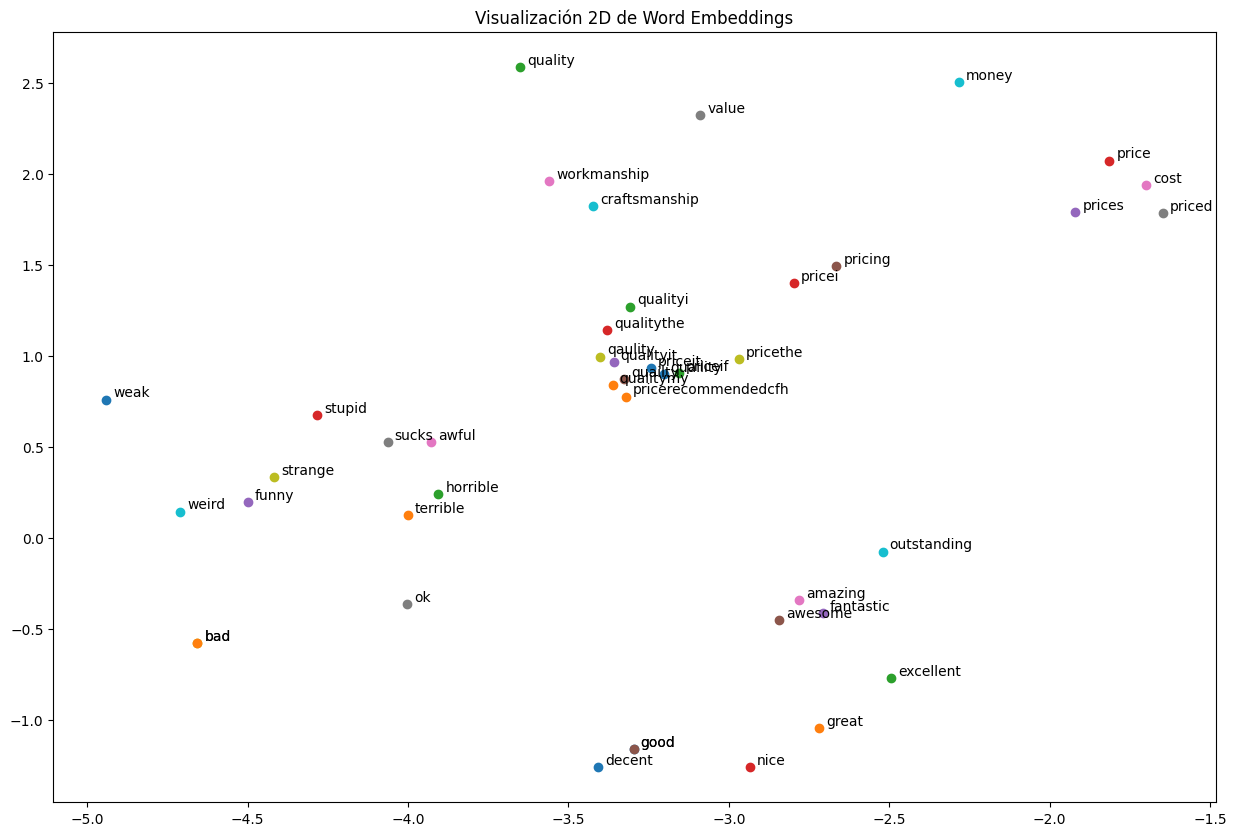

In [16]:
from sklearn.manifold import TSNE
import numpy as np

# Preparar datos para Word2Vec
sentences = [preprocess_text(review) for review in df['reviewText']]

# Entrenar modelo Word2Vec
modelW2vec = Word2Vec(sentences, vector_size=100, window=5, min_count=5)

# Visualizar palabras similares
def plot_similar_words(model, words):   
    word_vectors = []
    word_labels = []
    
    for word in words:
        try:
            # Obtener las 10 palabras más similares
            similar_words = [pair[0] for pair in model.wv.most_similar(word, topn=10)]
            similar_words.append(word)
            
            for similar_word in similar_words:
                word_vectors.append(model.wv[similar_word])
                word_labels.append(similar_word)
        except KeyError:
            continue
    
    # Convertir la lista a array de NumPy
    word_vectors = np.array(word_vectors)

    # Reducir dimensionalidad con t-SNE
    tsne = TSNE(n_components=2, random_state=0)
    vectors_2d = tsne.fit_transform(word_vectors)
    
    # Visualizar
    plt.figure(figsize=(15, 10))
    for i, label in enumerate(word_labels):
        x, y = vectors_2d[i]
        plt.scatter(x, y)
        plt.annotate(label, xy=(x, y), xytext=(5, 2), textcoords='offset points')
    
    plt.title('Visualización 2D de Word Embeddings')
    plt.show()

# Visualizar palabras ejemplo
plot_similar_words(modelW2vec, ['good', 'bad', 'quality', 'price'])

In [17]:
modelW2vec.save("word2vec_model.model")

In [18]:
%pip install torch torchtext

  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
   ---------------------------------------- 0.0/212.5 MB ? eta -:--:--
   -- ------------------------------------- 15.5/212.5 MB 88.4 MB/s eta 0:00:03
   ------- ------------------------------- 40.6/212.5 MB 107.7 MB/s eta 0:00:02
   ----------- --------------------------- 64.5/212.5 MB 111.1 MB/s eta 0:00:02
   ---------------- ---------------------- 88.9/212.5 MB 113.5 MB/s eta 0:00:02
   -------------------- ----------------- 113.0/212.5 MB 114.6 MB/s eta 0:00:01
   ---------------------- --------------- 126.4/212.5 MB 106.2 MB/s eta 0:00:01
   ------------------------- ------------ 143.1/212.5 MB 101.6 MB/s eta 0:00:01
   ----------------------------- --------- 159.1/212.5 MB 98.7 MB/s eta 0:00:01
   -------------------------------- ------ 175.1/212.5 MB 96.5 MB/s eta 0:00:01
   ----------------------------------- --- 191.9/212.5 MB 94.4 MB/s eta 0:00:01
   --------------------------------------  208.9/212.5 MB 93.4 M

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Preparar los datos
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=100):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        tokens = self.tokenizer(text)[:self.max_len]
        # Padding
        if len(tokens) < self.max_len:
            tokens = tokens + ['<pad>'] * (self.max_len - len(tokens))
        # Usar get() para manejar palabras desconocidas
        return torch.tensor([vocab.get(token, vocab['<unk>']) for token in tokens]), torch.tensor(self.labels[idx])

# 2. Modelo CNN
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, n_filters, filter_sizes, output_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels=1, out_channels=n_filters, 
                     kernel_size=(fs, embedding_dim)) 
            for fs in filter_sizes
        ])
        self.fc = nn.Linear(len(filter_sizes) * n_filters, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text):
        embedded = self.embedding(text)
        embedded = embedded.unsqueeze(1)
        conved = [torch.relu(conv(embedded)).squeeze(3) for conv in self.convs]
        pooled = [torch.max_pool1d(conv, conv.shape[2]).squeeze(2) for conv in conved]
        cat = self.dropout(torch.cat(pooled, dim=1))
        return self.fc(cat)

# 3. Modelo RNN (LSTM)
class TextRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers,
                           bidirectional=bidirectional, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text):
        embedded = self.embedding(text)
        output, (hidden, cell) = self.lstm(embedded)
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
        return self.fc(self.dropout(hidden))

# 4. Entrenamiento
def train_model(model, train_loader, valid_loader, optimizer, criterion, epochs=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    for epoch in range(epochs):
        model.train()
        for batch_idx, (text, labels) in enumerate(train_loader):
            text, labels = text.to(device), labels.to(device)
            optimizer.zero_grad()
            predictions = model(text)
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()
            
        # Evaluación
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for text, labels in valid_loader:
                text, labels = text.to(device), labels.to(device)
                outputs = model(text)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        print(f'Epoch: {epoch+1}, Accuracy: {100 * correct / total}%')

# 5. Configuración y entrenamiento
# Preparar datos
le = LabelEncoder()
# 0=negativo(<=2), 1=neutral(=3), 2=positivo(>=4)
df['sentiment'] = df['overall'].apply(lambda x: 2 if x >= 4 else (0 if x <= 2 else 1))  # 2=positivo, 0=negativo, 1=neutral

y_encoded = le.fit_transform(df['sentiment'])
X_train, X_test, y_train, y_test = train_test_split(df['reviewText'], y_encoded, test_size=0.2)

# Crear vocabulario
vocab = {'<pad>': 0, '<unk>': 1}  # Añadir token <unk> para palabras desconocidas

# # Crear vocabulario limitado a las palabras más frecuentes
# word_counts = Counter(all_tokens)
# most_common_words = [word for word, _ in word_counts.most_common(10000)]  # Top 10000 palabras
# for word in most_common_words:
#     vocab[word] = len(vocab)

for text in X_train:
    for token in preprocess_text(text):
        if token not in vocab:
            vocab[token] = len(vocab)

# Parámetros
VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 100
N_FILTERS = 100
FILTER_SIZES = [2, 3, 4]
OUTPUT_DIM = len(le.classes_)
DROPOUT = 0.5
BATCH_SIZE = 64

# Convertir las Series de pandas a listas porque el DataLoader de PyTorch está usando índices numéricos.
X_train = X_train.values.tolist()
X_test = X_test.values.tolist()
y_train = y_train.tolist()
y_test = y_test.tolist()
# Crear datasets y dataloaders
train_dataset = TextDataset(X_train, y_train, preprocess_text)
test_dataset = TextDataset(X_test, y_test, preprocess_text)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Entrenar CNN
cnn = TextCNN(VOCAB_SIZE, EMBEDDING_DIM, N_FILTERS, FILTER_SIZES, OUTPUT_DIM, DROPOUT)
optimizer = optim.Adam(cnn.parameters())
criterion = nn.CrossEntropyLoss()
train_model(cnn, train_loader, test_loader, optimizer, criterion)

# Entrenar RNN
rnn = TextRNN(VOCAB_SIZE, EMBEDDING_DIM, hidden_dim=256, output_dim=OUTPUT_DIM,
              n_layers=2, bidirectional=True, dropout=DROPOUT)
optimizer = optim.Adam(rnn.parameters())
train_model(rnn, train_loader, test_loader, optimizer, criterion)

Epoch: 1, Accuracy: 87.01997705338462%
Epoch: 2, Accuracy: 87.46541135182561%
Epoch: 3, Accuracy: 87.38948505095499%
Epoch: 4, Accuracy: 87.41648106904232%
Epoch: 5, Accuracy: 87.28487548086657%
Epoch: 1, Accuracy: 87.54133765269623%
Epoch: 2, Accuracy: 87.93784166835391%
Epoch: 3, Accuracy: 88.01208071809408%
Epoch: 4, Accuracy: 87.85010460957008%
Epoch: 5, Accuracy: 86.80063440642505%


In [22]:
# Guardar los modelos completos (arquitectura + pesos)
torch.save({
    'model_state_dict': cnn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'vocab': vocab,
    'model_params': {
        'vocab_size': VOCAB_SIZE,
        'embedding_dim': EMBEDDING_DIM,
        'n_filters': N_FILTERS,
        'filter_sizes': FILTER_SIZES,
        'output_dim': OUTPUT_DIM,
        'dropout': DROPOUT
    }
}, "cnn_model.pt")

torch.save({
    'model_state_dict': rnn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'vocab': vocab,
    'model_params': {
        'vocab_size': VOCAB_SIZE,
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dim': 256,
        'output_dim': OUTPUT_DIM,
        'n_layers': 2,
        'bidirectional': True,
        'dropout': DROPOUT
    }
}, "rnn_model.pt")